# **REDES SEQUENCE-TO-SEQUENCE** 

No material sobre autocompletar textos com *LSTM*, foi comentado sobre as diferentes sequências de *input/output* de uma rede, especialmente, a *many-to-many*, usada nesse material. Um importante problema de predição de sequência é a tradução de texto de uma língua natural para outra. Nesse caso, a sequência de *input* é uma frase no idioma de origem e a sequência de saída prevista é a frase correspondente no idioma de destino. Não é obrigatório que as duas frases tenham o mesmo número de palavras nos dois idiomas diferentes. Outra coisa importante é que a rede consuma toda a sequência de *input* antes de começar a emitir a sequência de *output*, porque, em muitos casos, é preciso considerar o significado completo de um frase para produzir uma boa tradução. Uma abordagem comum para isso é ensinar a rede a interpretar e emitir *tokens* de **START** e **STOP**, bem como valores de preenchimento (*padding*). Tanto o valor de preenchimento quanto os tokens de **START** e **STOP** devem ser valores que não aparecem naturalmente no texto. Por exemplo, com palavras representadas por índices que são entradas para uma camada de *embedding*, simplesmente reservaríamos índices específicos para esses *tokens*.

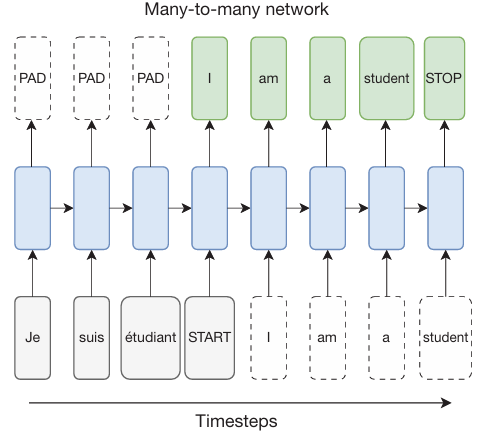 *Rede neural para tradução (many-to-many)*

A figura acima representra uma rede *many-to-many*, no qual o cinza representa o *input*, o azul é a rede e o verde é o *output*. A rede está desenrolada no tempo da esquerda para direita. A figura mostra que o comportamento desejado é que, durante os primeiros quatro passos de tempo, apresentemos os símbolos para *Je*, *suis*, *étudiant*, *START* à rede. No passo de tempo que a rede receber o token de *START*, ela produzirá a primeira palavra (*I*) da frase traduzida, seguida por *am*, *a*, *student* e *STOP*. Como sabemos, é impossível que a rede não produza um valor em uma passo de tempo, e, do mesmo jeito, a rede sempre receberá algum tipo de entrada. Isso é visto pelas formas brancas listradas a imagem. Uma solução simples para resolver isso seria usar o valor de preenchimento tanto na saída quanto na entrada para esses passos de tempo. No entanto, acontece que uma solução melhor é ajudar a rede alimentando a saída do passo de tempo anterior de volta como entrada para o próximo passo, assim como foi feito nos modelos de linguagem neurais nos materiais passados.

Ou seja, durante o treinamento, a rede verá tanto a sequência de origem quanto a de destino em sua entrada e será treinada para prever a sequência de destino em sua saída. Prever a sequência de destino como saída pode não parecer tão difícil, dado que a sequência de destino também é apresentada como entrada. No entanto, elas estão deslocadas no tempo, então a rede precisa prever a próxima palavra na sequência de destino antes de tê-la visto. Quando usamos a rede para produzir traduções, não temos a sequência de destino. Começamos alimentando a sequência de origem na rede, seguida pelo token de *START*, e então começamos a realimentar sua predição de saída como entrada para o próximo passo de tempo até que a rede produza um token de *STOP*. Nesse ponto, produzimos a frase traduzida completa.